<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/DBSCAN_Ejer3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [2]:
# ==========================================
# 1. CREAR DATAFRAME CON COLUMNAS MONTO Y HORA
# ==========================================
df = pd.read_csv('ejercicio_3_fraude_bancario.csv')
print("--- Muestra de las transacciones bancarias ---")
print(df.head())

--- Muestra de las transacciones bancarias ---
  Transaccion  Monto  Hora Perfil_Real
0          T1    510    13      Normal
1          T2    480    14      Normal
2          T3    550    12      Normal
3          T4    460    15      Normal
4          T5   4500     3  SOSPECHOSA


In [3]:
# ==========================================
# 2. ESCALAR LOS DATOS CON STANDARDSCALER
# ==========================================
# Justificación: La columna 'Monto' maneja miles de pesos/dólares, mientras que
# 'Hora' solo va de 0 a 24. Si no escalamos, el monto se comería por completo la variable horaria.
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df[['Hora', 'Monto']])

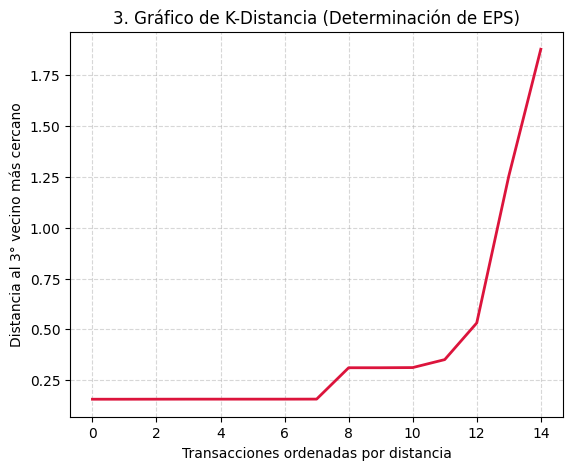

In [4]:
# ==========================================
# 3. GRÁFICO K-DISTANCIA PARA DETERMINAR EPS
# ==========================================
k = 3 # min_samples - 1 (para datos en 2D usaremos min_samples=4)
vecinos = NearestNeighbors(n_neighbors=k)
vecinos.fit(X_escalado)
distancias, _ = vecinos.kneighbors(X_escalado)
distancias_ordenadas = np.sort(distancias[:, k-1], axis=0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(distancias_ordenadas, color='crimson', lw=2)
plt.title('3. Gráfico de K-Distancia (Determinación de EPS)')
plt.xlabel('Transacciones ordenadas por distancia')
plt.ylabel(f'Distancia al {k}° vecino más cercano')
plt.grid(True, linestyle='--', alpha=0.5)

# El "codo" o punto de quiebre en datos escalados estándar suele ubicarse cerca de 0.3
eps_determinado = 0.3

In [5]:
# ==========================================
# 4. APLICAR DBSCAN Y ETIQUETAR (NORMAL VS SOSPECHOSA)
# ==========================================
dbscan = DBSCAN(eps=eps_determinado, min_samples=4)
df['Cluster'] = dbscan.fit_predict(X_escalado)

# Mapeamos los resultados: -1 es sospechosa (ruido/outlier), el resto es normal
df['Tipo_Transaccion'] = df['Cluster'].apply(lambda x: 'Sospechosa' if x == -1 else 'Normal')

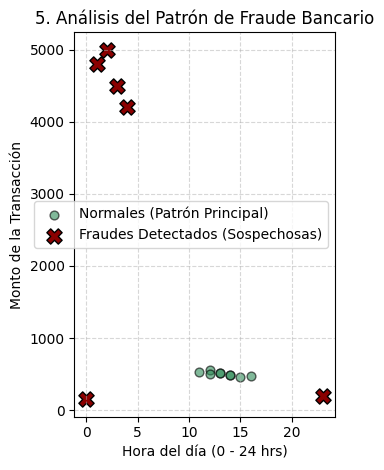

In [6]:
# ==========================================
# 5. GRAFICAR LAS TRANSACCIONES
# ==========================================
plt.subplot(1, 2, 2)

# Separamos los grupos para la visualización requerida
sospechosas = df[df['Tipo_Transaccion'] == 'Sospechosa']
normales_principal = df[df['Cluster'] == 0]
clusters_secundarios = df[(df['Cluster'] > 0)] # Otros patrones de gasto legítimo detectados

# Graficar transacciones normales (Cluster principal)
plt.scatter(normales_principal['Hora'], normales_principal['Monto'],
            color='seagreen', alpha=0.6, label='Normales (Patrón Principal)', edgecolors='k', s=40)

# Graficar clusters secundarios (Patrones normales alternativos, ej. compras nocturnas)
if not clusters_secundarios.empty:
    plt.scatter(clusters_secundarios['Hora'], clusters_secundarios['Monto'],
                color='royalblue', alpha=0.6, label='Normales (Patrón Secundario)', edgecolors='k', s=40)

# Resaltar los fraudes detectados (Sospechosas / Outliers)
plt.scatter(sospechosas['Hora'], sospechosas['Monto'],
            color='darkred', marker='X', s=120, label='Fraudes Detectados (Sospechosas)', edgecolors='black')

plt.title('5. Análisis del Patrón de Fraude Bancario')
plt.xlabel('Hora del día (0 - 24 hrs)')
plt.ylabel('Monto de la Transacción')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
# ==========================================
# 6. CALCULAR EL PORCENTAJE DE SOSPECHOSAS
# ==========================================
total_transacciones = len(df)
total_sospechosas = len(sospechosas)
porcentaje_sospechosas = (total_sospechosas / total_transacciones) * 100

print("\n" + "="*50)
print(f"6. MÉTRICAS DE FRAUDE DETECTADAS:")
print(f"-> Total de transacciones analizadas: {total_transacciones}")
print(f"-> Transacciones marcadas como sospechosas: {total_sospechosas}")
print(f"-> Porcentaje de transacciones sospechosas: {porcentaje_sospechosas:.2f}%")
print("="*50)


6. MÉTRICAS DE FRAUDE DETECTADAS:
-> Total de transacciones analizadas: 15
-> Transacciones marcadas como sospechosas: 6
-> Porcentaje de transacciones sospechosas: 40.00%


7. Reflexión: ¿Qué ventaja tiene DBSCAN sobre K-Means para detectar fraude?En el ámbito del fraude bancario, DBSCAN es sustancialmente superior a K-Means por tres motivos estratégicos:No requiere definir el número de fraudes de antemano: Con K-Means necesitas decirle al algoritmo cuántos grupos ($K$) buscar. En el fraude del mundo real, tú no sabes de antemano cuántos tipos de fraude van a ocurrir ni cuántas transacciones delictivas habrá. DBSCAN descubre los grupos densos (comportamiento normal) y aísla el resto de forma orgánica.El fraude es, por definición, un "outlier" (ruido): K-Means no tolera el ruido; obliga a cada transacción fraudulenta a meterse a la fuerza dentro de un grupo de transacciones legítimas. Esto no solo provoca que no detectes el fraude, sino que además corrompe y "ensucia" el perfil matemático de los clientes honestos. DBSCAN maneja nativamente el concepto de ruido asignándole la etiqueta -1.Forma geométrica de los hábitos de consumo: Las transacciones legítimas no forman círculos perfectos en un gráfico. Los patrones de gasto legítimos suelen tener formas irregulares (por ejemplo, picos de uso a la hora del almuerzo o salidas del trabajo). DBSCAN puede agrupar agrupaciones de densidades con formas completamente arbitrarias, aislando con extrema precisión lo que quede fuera de la rutina social colectiva.